# Testing DRT fitting

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, ResidualsPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData, ResidualsData
from redoxed.impedance.drt_analysis import HN_Z, HN_DRT, SG_DRT, fit_DRT_peaks, find_DRT_peaks
from redoxed.dc import PolarisationData

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

%matplotlib inline

# if think is slowing down, disable autoreload by restarting kernel without it.
%load_ext autoreload
%autoreload 2 

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## DRT (Loop)

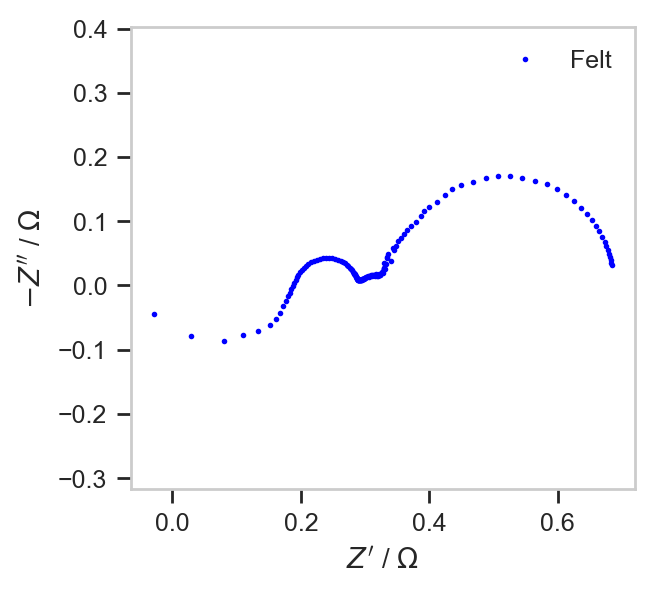

ed's tau adjustment made


c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:59: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_i, -50, 50, epsabs=1E-9, epsrel=1E-9)
c:\users\es758\documents\github\pydrttools\pyDRTtools\basics.py:92: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  out_val = integrate.quad(integrand_g_ii, -50, 50, epsabs=1E-9, epsrel=1E-9)


The value of the regularization parameter is 1e-09
     pcost       dcost       gap    pres   dres
 0: -2.0981e+01 -2.3668e+01  2e+02  1e+01  6e-06
 1: -2.0495e+01 -2.4286e+01  3e+01  2e+00  9e-07
 2: -2.0729e+01 -2.2959e+01  2e+00  2e-02  9e-09
 3: -2.0896e+01 -2.1458e+01  6e-01  4e-03  2e-09
 4: -2.0960e+01 -2.1191e+01  2e-01  4e-05  2e-11
 5: -2.0987e+01 -2.1037e+01  5e-02  6e-06  3e-12
 6: -2.0999e+01 -2.1017e+01  2e-02  7e-07  4e-13
 7: -2.1001e+01 -2.1006e+01  5e-03  2e-07  9e-14
 8: -2.1002e+01 -2.1005e+01  3e-03  6e-08  3e-14
 9: -2.1003e+01 -2.1003e+01  6e-04  9e-09  4e-15
10: -2.1003e+01 -2.1003e+01  2e-04  2e-16  9e-16
11: -2.1003e+01 -2.1003e+01  3e-05  3e-16  1e-15
12: -2.1003e+01 -2.1003e+01  6e-06  2e-16  4e-17
Optimal solution found.
R = 3.514301195095685e-07, L = 7.372453821682098e-08, lambda = 1e-09


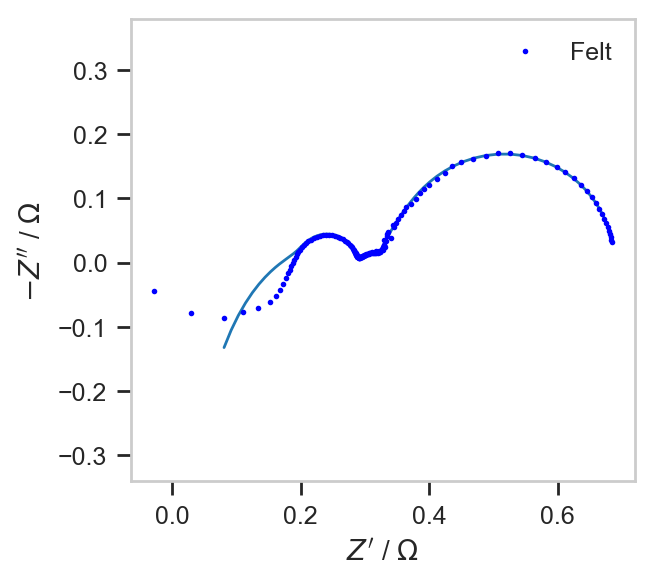

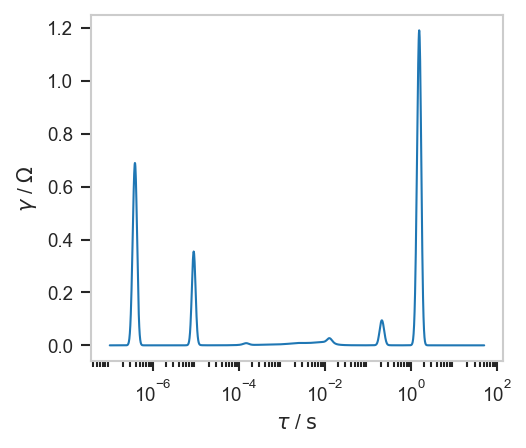

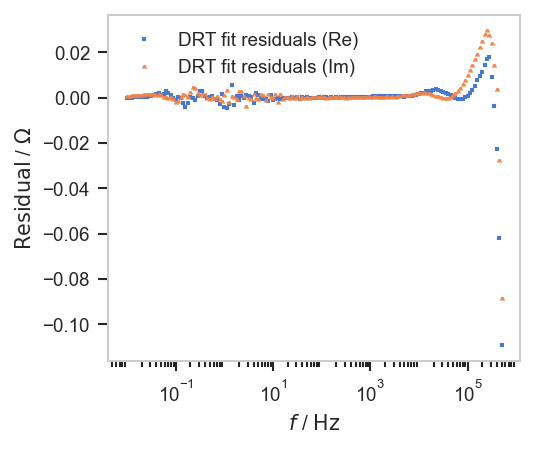

In [47]:
import pyDRTtools

EISData_array = []
fitted_EISData_array = []
DRTData_array = []
R_array = []
L_array = []

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.03.06 FB1_FCN_KCl_E620K_GFDBO_B3cutedge\1_50ml_50soc_20mM_FCN_33rpm_air_03_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 6)
EISData_object = ECData_object.to_EISData()
EISData_object.label = "Felt"
EISData_array.append(EISData_object)

lambda_0 = 1e-9 # initial guess for regularization parameter

NyquistPlot_object = NyquistPlot(figsize=(3.25, 3), dpi=200) 

for i, EISData_object in enumerate(EISData_array):
    # EISData_object.trim_inductive()
    #EISData_object.crop_frequency(0.01, 2e5)
    NyquistPlot_object.add_plot(EISData_object, linestyle = "", marker = "o", markersize = 1, color = 'blue', zorder = 3)

NyquistPlot_object.ax.legend()
display(NyquistPlot_object.fig)

DRTPlot_object = DRTPlot(figsize=(3.543, 3), dpi = 150)
ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'absolute')
# ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative')




for i, EISData_object in enumerate(EISData_array):
    # Load measurement data into EIS_object
    pyDRTtools_EIS_object = pyDRTtools.runs.EIS_object(
        EISData_object.f, EISData_object.Z_re, EISData_object.Z_im, ed_adjust = True
    )
    # this includes tau definition of
    # # self.tau = 1/freq # we assume that the collocation points equal to 1/freq as default
    # # self.tau_fine  = np.logspace(log10(self.tau.min())-0.5,log10(self.tau.max())+0.5,10*freq.shape[0]
    
    lambda_0 = lambda_0 # initial guess

    induct_used = 1 # 1 means do keep inductive and fit inductance.
    der_used = '1st order'
    cv_type = 'custom' # fix lambda

    reg_param = lambda_0
    shape_control = "FWHM Coefficient" # otherwise coeff is treated as their definition of shape factor mu
    coeff = 0.5 # FWHM twice log spacing means coef 0.5. Is done so there is good overlap.
    rbf_type = "Gaussian" # Gaussian is the default, but can also use 'Cauchy', 'Lorentzian', 'Exponential', 'Polynomial', 'Ridge' or 'Laplacian'
    data_used = "Combined Re-Im Data"
    # ridge regression DRT
    fitted_entry = pyDRTtools.runs.simple_run(
        entry=pyDRTtools_EIS_object,
        rbf_type=rbf_type,
        data_used=data_used,
        induct_used=induct_used,
        der_used=der_used,
        cv_type=cv_type,
        reg_param=reg_param,
        shape_control=shape_control,
        coeff=coeff,
    )
    ### If want to mute the console, can use something like this with simple_run nested in
    # # Redirecting stdout to capture the output
    # with io.StringIO() as output, contextlib.redirect_stdout(output):

    gamma_pyDRTtools = fitted_entry.gamma # is tau_fine from DRTtools, not tau used for fitting x. padded values.
    tau_pyDRTtools = fitted_entry.out_tau_vec
    DRT_object_pyDRTtools = DRTData(tau = tau_pyDRTtools, gamma = gamma_pyDRTtools, label = EISData_object.label)
    R_pyDRTtools = fitted_entry.R
    L_pyDRTtools = fitted_entry.L
    lambda_value_pyDRTtools = fitted_entry.lambda_value 
    f_pyDRTtools = fitted_entry.freq
    Z_pyDRTtools = fitted_entry.mu_Z_re + 1j*fitted_entry.mu_Z_im
    EISData_fitted_pyDRTtools = EISData(f = fitted_entry.freq, Z = Z_pyDRTtools, label = "DRT fit")
    ResidualsData_object = ResidualsData().calculate_residuals(observed = EISData_object, predicted = EISData_fitted_pyDRTtools, label = "DRT fit residuals")

    fitted_EISData_array.append(EISData_fitted_pyDRTtools)
    DRTData_array.append(DRT_object_pyDRTtools)
    R_array.append(R_pyDRTtools)
    L_array.append(L_pyDRTtools)

    print(f"R = {R_pyDRTtools}, L = {L_pyDRTtools}, lambda = {lambda_value_pyDRTtools}")

    NyquistPlot_object.add_plot(EISData_fitted_pyDRTtools, linestyle = "-", marker = "", linewidth = 1, color = tab10_colors[i])

    DRTPlot_object.add_plot(DRT_object_pyDRTtools, linestyle = "-", marker = "", color = tab10_colors[i], linewidth =1)
    
    ResidualsPlot_object.add_plot(ResidualsData_object, linestyle = "", markersize = 1)  
ResidualsPlot_object.ax.legend()
# DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
display(NyquistPlot_object.fig)
display(DRTPlot_object.fig)
display(ResidualsPlot_object.fig)


[199079.58 177432.83 158142.81 140940.47 125621.66 111954.42]


,Element,Parameter,Value,Std. err. (%),Unit,Fixed
0,La_0,L,1.477226e-08,20.381654,H*s^(n-1),No
1,La_0,n,1.000000e+00,1.130917,,No
2,R_1,R,1.796595e-01,1.807357,ohm,No


,Label,Value
0,Log pseudo chi-squared,-1.742258
1,Log chi-squared,-4.198519
2,Log chi-squared (reduced),-5.152761
3,Akaike info. criterion,-139.828238
4,Bayesian info. criterion,-138.373518
5,Degrees of freedom,9
6,Number of data points,12
7,Number of function evaluations,123
8,Method,least_squares
9,Weight,boukamp


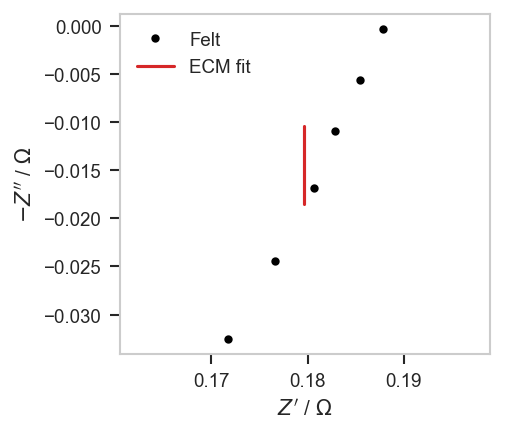

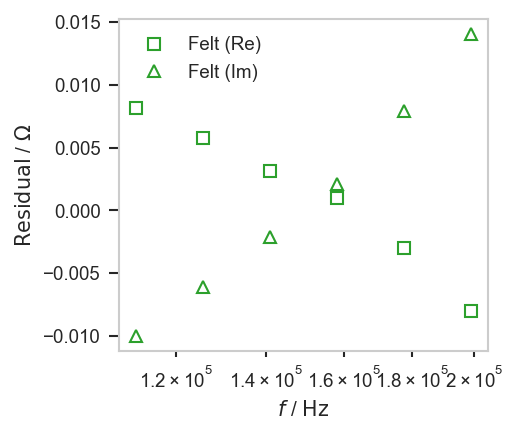

In [48]:
from pyimpspec import (
    ComplexImpedances,    # Alias for a NumPy array of complex128 values
    Frequencies,          # Alias for a NumPy array of float64 values
    Circuit,
    DataSet,
    FitResult,
    Element,              # The base class for all circuit elements
    ElementDefinition,    # A class that contains information regarding a new circuit element
    ParameterDefinition,  # A class that contains information regarding a circuit element's parameter
    register_element,     # A function that processes the new element class
    parse_cdc,
    fit_circuit,
)

# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
residuals_plot_dict = {}

#########################
##### Data loading ######
#########################

fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.03.06 FB1_FCN_KCl_E620K_GFDBO_B3cutedge\1_50ml_50soc_20mM_FCN_33rpm_air_03_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 6)
EISData_object = ECData_object.to_EISData()
# EISData_object.crop_frequency(0.01, 2e5)
EISData_object.crop_frequency(1e5, 2e5)
EISData_object.label = "Felt"
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

#########################
#### Circuit fitting ####
#########################
print(EISData_object.f)
data: DataSet = DataSet(frequencies = EISData_object.f, impedances= EISData_object.Z, mask = None, path = "", label = EISData_object.label, uuid = "")
# circuit: Circuit = parse_cdc("[LR(Q[RWs])]")
circuit: Circuit = parse_cdc("[LaR]")
fit: FitResult = fit_circuit(
  circuit, 
  data,
  method = "least_squares",
  weight = "boukamp",  
  max_nfev=-1, num_procs=-1, timeout=0, constraint_expressions=None, constraint_variables=None)
freq_fit, real_resid_percent, imag_resid_percent = fit.get_residuals_data() 
real_z, neg_imag_z = fit.get_nyquist_data(num_per_decade=-1) # default is frequency points used for fit, otherwise can set to make more refined.
EISData_circuit = EISData(Z = real_z - 1j * neg_imag_z, f = freq_fit, label = "ECM fit")
eis_plot_dict[EISData_circuit.label] = {
        "data": EISData_circuit,
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "-", "marker": "", "label": EISData_circuit.label},
        "plot": True
    }
## show results
df: pd.DataFrame = fit.to_parameters_dataframe(running=True) # set true to start from 0
# parameters: str = df.to_markdown(index=False)
parameters = df
df = fit.to_statistics_dataframe()
# statistics: str = df.to_markdown(index=False)
statistics = df
# display(Markdown(parameters))
# display(Markdown(statistics))
display(parameters)
display(statistics)
# ## simulate
# # data: DataSet = simulate_spectrum(fit.circuit, frequencies=np.logspace(3, 0, num=16), label="Randles")
# # fit.circuit.get_elements()[-1].get_values()
# ## show drawing
# drawing: Drawing = circuit.to_drawing(running=True, hide_labels = True)
# ## Useful other arguments
# # hide_labels: bool = False,
# # running: bool = False,
# # custom_labels: Optional[Dict[Element, str]] = None,
# # canvas: Optional[Union[str, "Axes"]] = None,  # noqa: F821
# display(drawing)
# #drawing.save(fname = "simple_circuit.svg", transparent = True, dpi = 72)

#########################
### Circuit Residuals ###
#########################

observed = EISData_object
predicted = EISData_circuit
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["green"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
        "plot": True
    }

#########################
##### DRT fitting #######
#########################

# DRTData_object = DRTData(gamma=gamma, tau=tau)
# DRTData_object.label = "DRT exact"
# drt_plot_dict[DRTData_object.label] = {
#         "data": DRTData(gamma=gamma, tau=tau),
#         "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_object.label},
#         "plot": True
#     }



#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(3.543, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

# #########################
# #### Create DRT Plot ####
# #########################
# DRTPlot_object = DRTPlot(figsize=(3.543, 3), dpi = 150)
# for label, entry in drt_plot_dict.items():
#     if entry["plot"]:
#         DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# DRTPlot_object.add_major_ticks(spacing_y = 1)
# # # DRTPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
# DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
# DRTPlot_object.fig.tight_layout() # try stop cutting off labels
# display(DRTPlot_object.fig)
# # DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
# ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative') # gets a bit misleading for small Z
ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'absolute')
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)